In [ ]:
!pip install transformers==4.36.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3
    Uninstalling transformers-4.51.3:
      Successfully uninstalled transformers-4.51.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.


In [ ]:
!pip install accelerate==0.25.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
!pip install peft==0.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.14.0
    Uninstalling peft-0.14.0:
      Successfully uninstalled peft-0.14.0


In [1]:
import transformers
import accelerate
import peft
print(transformers.__version__)
print(accelerate.__version__)
print(peft.__version__)


/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


4.36.2
0.25.0
0.7.1


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.utils.data import Dataset


In [4]:
df_balanced = pd.read_csv('/content/balanced_reddit_data.csv')
df_balanced['text'] = df_balanced['text'].fillna("").astype(str)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_balanced['text'].tolist(),
    df_balanced['label'].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df_balanced['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'nreimers/MiniLM-L6-H384-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)


train_texts = [str(text) if text is not None else "" for text in train_texts]
val_texts = [str(text) if text is not None else "" for text in val_texts]
test_texts = [str(text) if text is not None else "" for text in test_texts]

def batch_tokenize(texts, tokenizer, batch_size=2500, max_length=128):
    input_ids = []
    attention_masks = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        input_ids.append(encodings['input_ids'])
        attention_masks.append(encodings['attention_mask'])
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    return {'input_ids': input_ids, 'attention_mask': attention_masks}

train_encodings = batch_tokenize(train_texts, tokenizer)
val_encodings = batch_tokenize(val_texts, tokenizer)
test_encodings = batch_tokenize(test_texts, tokenizer)

train_labels = torch.tensor(train_labels, dtype=torch.long)
val_labels = torch.tensor(val_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
class RedditDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

train_dataset = RedditDataset(train_encodings, train_labels)
val_dataset = RedditDataset(val_encodings, val_labels)
test_dataset = RedditDataset(test_encodings, test_labels)


In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.config.problem_type = "single_label_classification"
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nreimers/MiniLM-L6-H384-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, e

In [8]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=False,
    logging_dir='./logs',
    logging_steps=500
)


In [9]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


In [10]:
from transformers import Trainer, EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)


In [11]:
trainer.train()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: ammarrousan (ammarrousan-it-glue) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.167900,0.158576,0.940826,0.941219,0.935013,0.947507


Checkpoint destination directory ./results/checkpoint-18620 already exists and is non-empty.Saving will proceed but saved results may be invalid.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.167900,0.158576,0.940826,0.941219,0.935013,0.947507
2,0.138600,0.152030,0.944782,0.945153,0.938828,0.951564
3,0.127900,0.154492,0.945855,0.946309,0.938430,0.954321


TrainOutput(global_step=55860, training_loss=0.15364021638623712, metrics={'train_runtime': 6777.1681, 'train_samples_per_second': 263.747, 'train_steps_per_second': 8.242, 'total_flos': 1.4820614661146112e+16, 'train_loss': 0.15364021638623712, 'epoch': 3.0})

In [12]:
print(" Final Evaluation on Test Set")
trainer.evaluate(test_dataset)


 Final Evaluation on Test Set


{'eval_loss': 0.1510322093963623,
 'eval_accuracy': 0.9468106770262227,
 'eval_f1': 0.9472039307454889,
 'eval_precision': 0.9402522033061168,
 'eval_recall': 0.9542592186472008,
 'eval_runtime': 160.929,
 'eval_samples_per_second': 793.369,
 'eval_steps_per_second': 24.794,
 'epoch': 3.0}

In [13]:
print("Extracting predictions for analysis...")
predictions_output = trainer.predict(test_dataset)
all_preds = predictions_output.predictions.argmax(-1)
all_labels = predictions_output.label_ids

Extracting predictions for analysis...


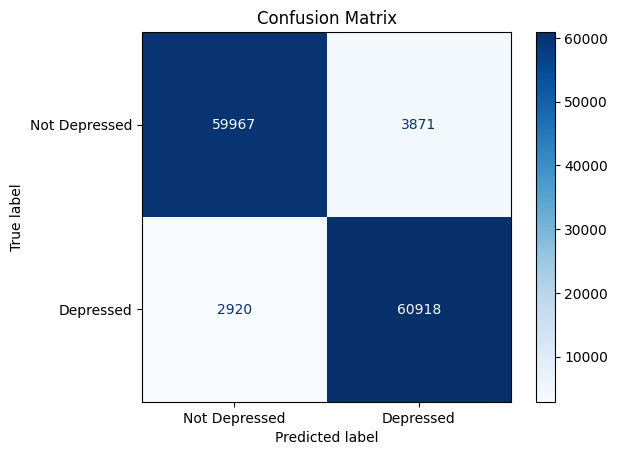

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(all_labels, all_preds, class_names=['Not Depressed', 'Depressed'])

In [15]:
import pandas as pd
import numpy as np

def show_misclassified_samples(texts, labels, preds, num_samples=10):
    misclassified_indices = np.where(labels != preds)[0]
    num_samples = min(num_samples, len(misclassified_indices))
    sampled_indices = np.random.choice(misclassified_indices, size=num_samples, replace=False)
    data = {
        "Text": [texts[i] for i in sampled_indices],
        "True Label": [labels[i] for i in sampled_indices],
        "Predicted Label": [preds[i] for i in sampled_indices],
    }
    df = pd.DataFrame(data)
    print(df)

show_misclassified_samples(test_texts, all_labels, all_preds, num_samples=10)

                                                Text  True Label  \
0  im at a great place in life but i still feel l...           0   
1  my kids just broke my heart so im having a fig...           1   
2  i got out of a ten day stay at the hospital fo...           0   
3  conditioned to be stressed i have been conditi...           0   
4  senior in high school and feeling like ive was...           0   
5  so i thought this year was going to be shitty ...           0   
6  schools out for me now i dont have to die ever...           0   
7  is it bad that my aspirations of becoming a di...           0   
8  how do you make new friends i go to a small ch...           0   
9  feeling worthless over grades very new to this...           0   

   Predicted Label  
0                1  
1                0  
2                1  
3                1  
4                1  
5                1  
6                1  
7                1  
8                1  
9                1  


In [16]:
from sklearn.metrics import classification_report

def print_classification_report(y_true, y_pred, class_names=None):
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)

print_classification_report(all_labels, all_preds, class_names=['Not Depressed', 'Depressed'])

               precision    recall  f1-score   support

Not Depressed       0.95      0.94      0.95     63838
    Depressed       0.94      0.95      0.95     63838

     accuracy                           0.95    127676
    macro avg       0.95      0.95      0.95    127676
 weighted avg       0.95      0.95      0.95    127676



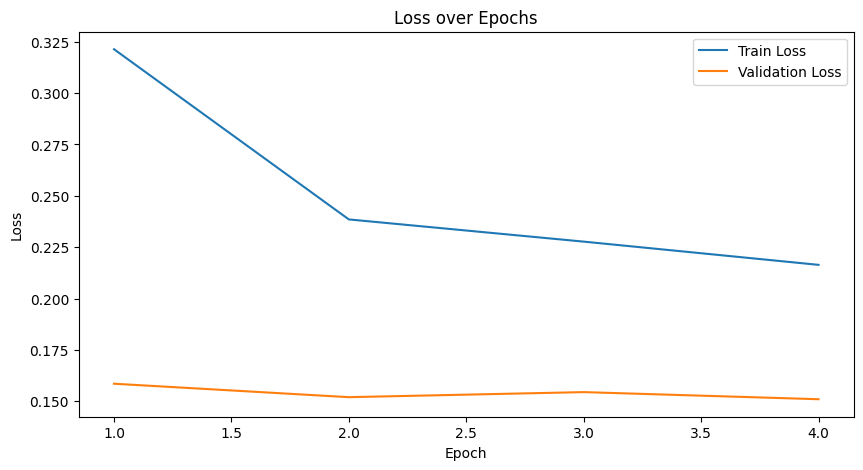

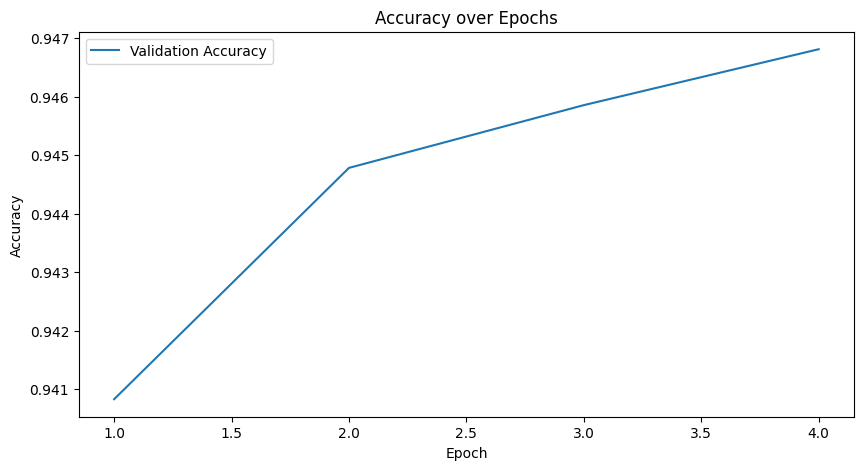

In [19]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [log['loss'] for log in logs if 'loss' in log and 'epoch' in log]
eval_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]
eval_accuracy = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]
epochs = list(range(1, len(eval_loss) + 1))

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss[:len(eval_loss)], label='Train Loss')
plt.plot(epochs, eval_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, eval_accuracy, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [22]:
import json

test_results = trainer.evaluate(test_dataset)

with open('test_results.json', 'w') as f:
    json.dump(test_results, f, indent=4)

df_results = pd.DataFrame([test_results])
df_results.to_excel('test_results.xlsx', index=False)

print(" Test results saved to JSON and Excel.")


 Test results saved to JSON and Excel.


In [23]:
from transformers import AutoModelForSequenceClassification

model_with_attention = AutoModelForSequenceClassification.from_pretrained(
    '/content/saved_model_nreimers_MiniLM',
    output_attentions=True
)
model_with_attention.to(device)
model_with_attention.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, e

In [21]:
save_directory = './saved_model_nreimers_MiniLM'
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)
print(" Model Saved and tokenizer.")


 Model Saved and tokenizer.


In [24]:
# Select a few test samples
sample_texts = test_texts[:10]

# Tokenize
encodings = tokenizer(
    sample_texts,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64
)
encodings = {k: v.to(device) for k, v in encodings.items()}

# Forward pass to get attentions
with torch.no_grad():
    outputs = model_with_attention(**encodings, output_attentions=True)
    attentions = outputs.attentions

In [25]:
last_layer_attention = attentions[-1]

avg_attention = last_layer_attention.mean(dim=1)

cls_attention = avg_attention[:, 0, :]

cls_attention = cls_attention.detach().cpu().numpy()

In [29]:
# Block 1: Load model and select short samples
import torch
from transformers import AutoModelForSequenceClassification
import random

# Load model
model_with_attention = AutoModelForSequenceClassification.from_pretrained(
    '/content/saved_model_nreimers_MiniLM',  # Change path if needed
    output_attentions=True
)
model_with_attention.to(device)
model_with_attention.eval()

# Select only short samples
short_samples = [(i, text) for i, text in enumerate(test_texts) if len(text.split()) <= 20]
selected = random.sample(short_samples, 10)
sample_indices = [idx for idx, _ in selected]
sample_texts = [text for _, text in selected]
sample_true_labels = [test_labels[idx].item() for idx in sample_indices]

# Tokenize
encodings = tokenizer(
    sample_texts,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64
)
encodings = {k: v.to(device) for k, v in encodings.items()}

In [30]:
# Block 2: Forward pass
with torch.no_grad():
    outputs = model_with_attention(**encodings, output_attentions=True, return_dict=True)
    attentions = outputs.attentions
    logits = outputs.logits

# Average Attention across all layers
# attentions = list of tensors (batch, heads, seq_len, seq_len)
# First average over heads -> (batch, seq_len, seq_len)
avg_attn_per_layer = [att.mean(dim=1) for att in attentions]
# Then average over all layers -> (batch, seq_len, seq_len)
mean_attention = torch.stack(avg_attn_per_layer).mean(dim=0)

# Extract attention from CLS token
cls_attention = mean_attention[:, 0, :].detach().cpu().numpy()

# Decode tokens (cleaned)
decoded_tokens_list = []
for input_ids in encodings['input_ids']:
    tokens = tokenizer.convert_ids_to_tokens(input_ids, skip_special_tokens=True)
    tokens_clean = [token.replace('##', '') for token in tokens]  # remove subwords indicators
    decoded_tokens_list.append(tokens_clean)

# Get predicted classes
predicted_classes = logits.argmax(dim=1).detach().cpu().numpy()

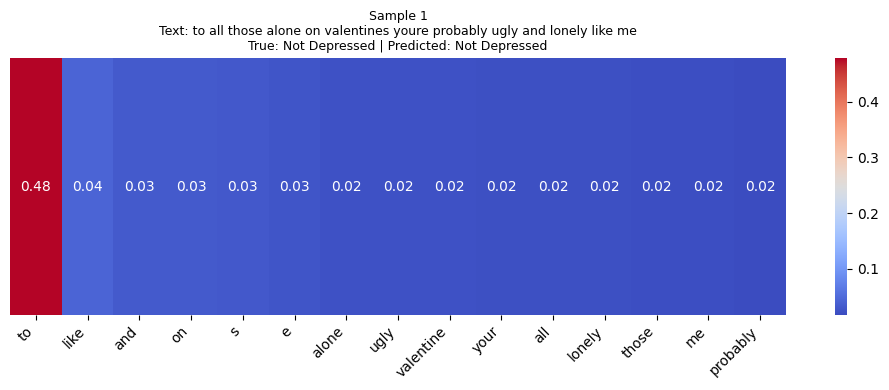

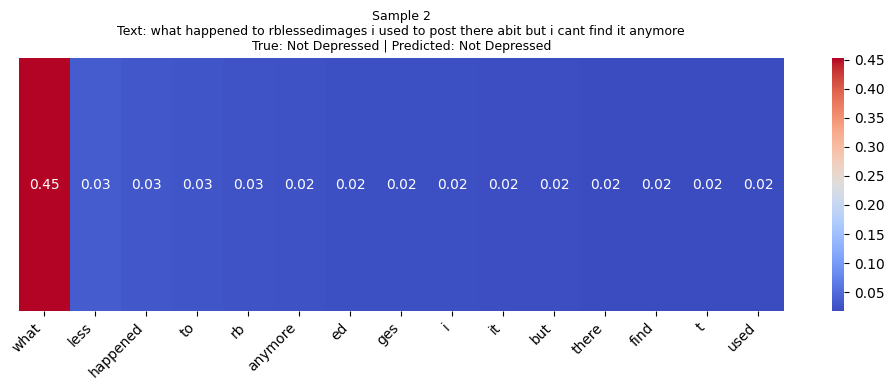

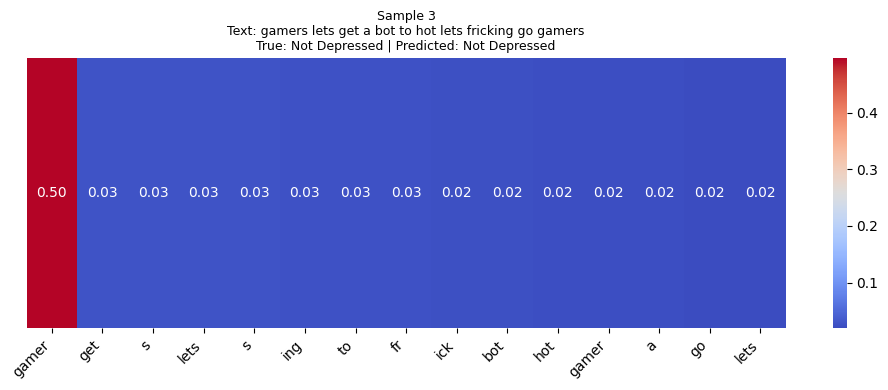

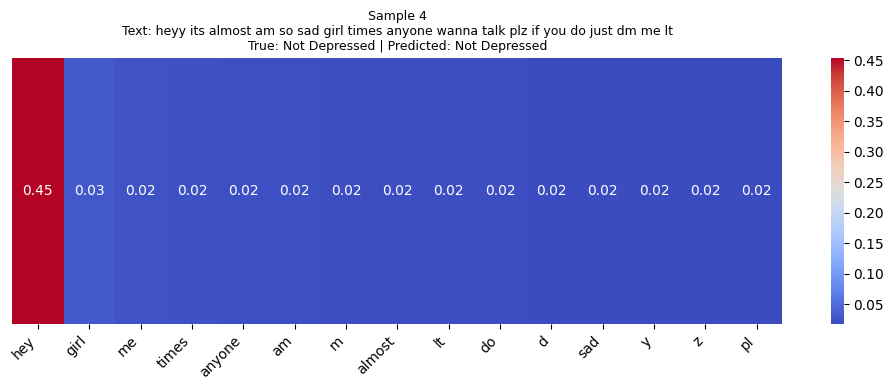

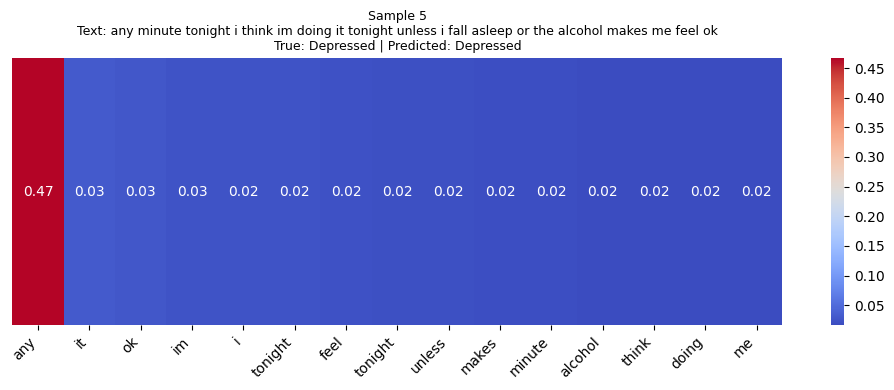

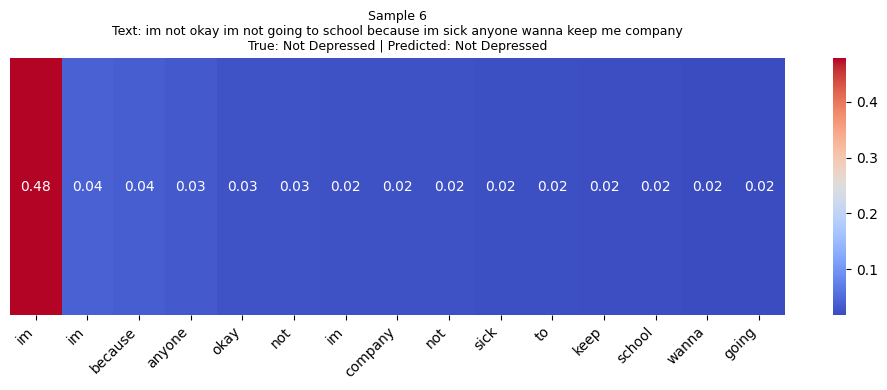

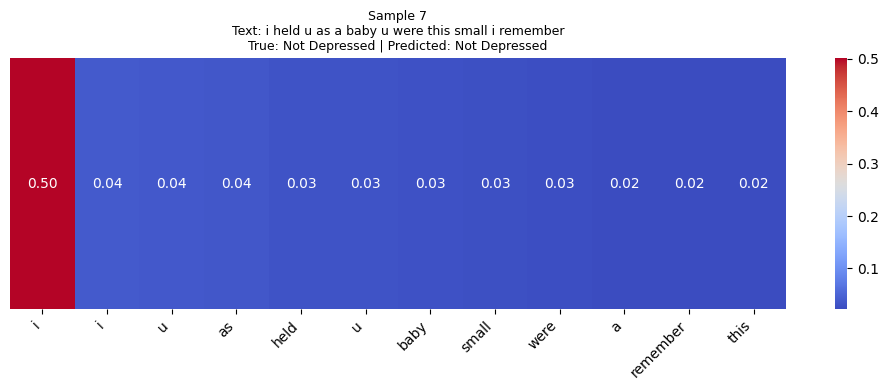

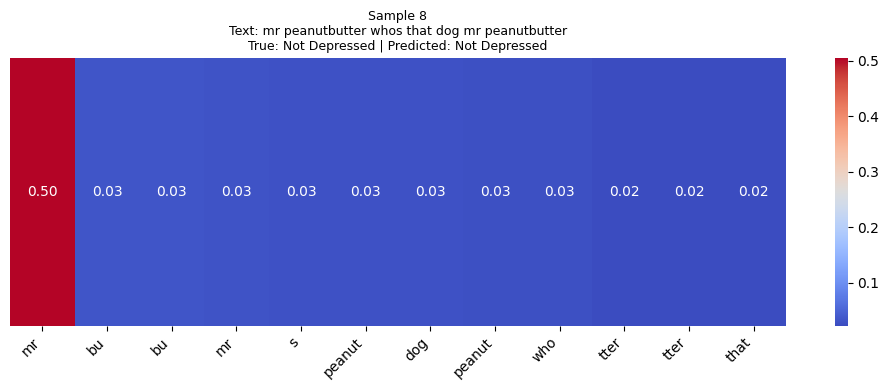

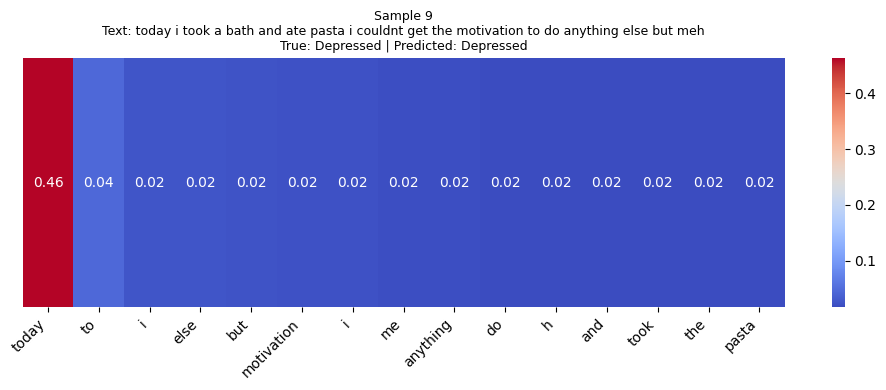

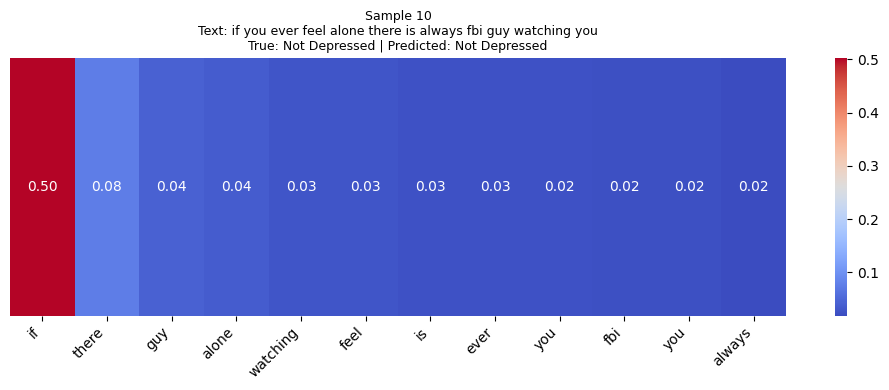

In [31]:
# Block 3: Plot smart clean heatmaps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for i in range(len(sample_texts)):
    tokens = decoded_tokens_list[i]
    attention_scores = cls_attention[i][:len(tokens)]  # crop to non-padding tokens

    # Remove tokens with very low attention (< 0.01)
    filtered_tokens = []
    filtered_attentions = []
    for token, score in zip(tokens, attention_scores):
        if score >= 0.01:
            filtered_tokens.append(token)
            filtered_attentions.append(score)

    # Sort by highest attention
    sorted_indices = np.argsort(filtered_attentions)[::-1]
    top_k = min(15, len(sorted_indices))  # Top 15 tokens
    top_tokens = [filtered_tokens[j] for j in sorted_indices[:top_k]]
    top_attentions = [filtered_attentions[j] for j in sorted_indices[:top_k]]

    # Dynamic figure size
    fig_width = max(10, len(top_tokens) * 0.6)

    plt.figure(figsize=(fig_width, 4))
    sns.heatmap(
        [top_attentions],
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        xticklabels=top_tokens,
        cbar=True
    )

    predicted_label = 'Depressed' if predicted_classes[i] == 1 else 'Not Depressed'
    true_label = 'Depressed' if sample_true_labels[i] == 1 else 'Not Depressed'

    plt.title(
        f"Sample {i+1}\nText: {sample_texts[i][:200]}{'...' if len(sample_texts[i]) > 200 else ''}\nTrue: {true_label} | Predicted: {predicted_label}",
        fontsize=9
    )

    plt.xticks(rotation=45, ha='right')
    plt.yticks([])
    plt.tight_layout()
    plt.show()